# Scorecard Generation & Tuning: Medical Procedure Loan Default Risk

**Objective:** Build, validate, and tune a credit scorecard for predicting default risk on medical procedure loans.

**Input Data:**
- Prepared dataset: 252,136 rows  21 features
- Fair lending compliant (protected classes excluded)
- 11 selected features (IV  0.02, Min_Bin  5%)

**Output:**
- WOE-encoded features using scorecardpy
- Logistic regression model with hyperparameter tuning
- Credit scorecard with risk categories
- Model performance evaluation

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=0.9)

## 1. Data Loading

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=0.9)

# Load WOE-encoded data from notebook 3
df = pd.read_csv('../data/model_data.csv')
print(f"Loaded WOE-encoded data: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Data source: Generated by 3_grouping_and_screening.ipynb (WOE-encoded features)")
print("\nTarget distribution:")
print(df['TARGET'].value_counts())
print("\nClass proportions:")
print(df['TARGET'].value_counts(normalize=True))


Loaded WOE-encoded data: 252,136 rows x 14 columns
Data source: Generated by 3_grouping_and_screening.ipynb (WOE-encoded features)

Target distribution:
TARGET
0    230301
1     21835
Name: count, dtype: int64

Class proportions:
TARGET
0    0.9134
1    0.0866
Name: proportion, dtype: float64


In [159]:
# Data Preprocessing: Handle missing values (all features are WOE-encoded numerics)
df_clean = df.copy()

# Check for missing values
missing_counts = df_clean.isnull().sum()
print("Missing values by feature:")
print(missing_counts[missing_counts > 0])

# Fill missing values with median
for col in df_clean.columns:
    if col != 'TARGET' and df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"  {col}: filled {missing_counts[col]} NaN with median = {median_val:.6f}")

# Separate features and target
X = df_clean.drop(columns=['TARGET'])
y = df_clean['TARGET']

print(f"\nFeature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names:")
print(X.columns.tolist())

Missing values by feature:
Series([], dtype: int64)

Feature matrix X shape: (252136, 13)
Target vector y shape: (252136,)
Number of features: 13

Feature names:
['avg_days_credit_woe', 'debt_to_credit_woe', 'DAYS_EMPLOYED_woe', 'OCCUPATION_TYPE_woe', 'AMT_GOODS_PRICE_woe', 'NAME_EDUCATION_TYPE_woe', 'REGION_RATING_CLIENT_W_CITY_woe', 'DAYS_LAST_PHONE_CHANGE_woe', 'num_active_woe', 'ORGANIZATION_TYPE_woe', 'NAME_INCOME_TYPE_woe', 'EMERGENCYSTATE_MODE_woe', 'HOUSETYPE_MODE_woe']


In [160]:
# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("=" * 70)
print("STRATIFIED TRAIN-TEST SPLIT (70% train / 30% test)")
print("=" * 70)
print(f"\nTraining set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTraining set class distribution:")
train_dist = y_train.value_counts(normalize=True).sort_index()
for label, prop in train_dist.items():
    count = y_train.value_counts()[label]
    print(f"  Class {label}: {count:>7,} samples ({prop*100:5.2f}%)")

print(f"\nTest set class distribution:")
test_dist = y_test.value_counts(normalize=True).sort_index()
for label, prop in test_dist.items():
    count = y_test.value_counts()[label]
    print(f"  Class {label}: {count:>7,} samples ({prop*100:5.2f}%)")

print(f"\nStratification check (proportions match):")
print(f"  Original:  {y.value_counts(normalize=True).sort_index().values}")
print(f"  Train:     {train_dist.values}")
print(f"  Test:      {test_dist.values}")

STRATIFIED TRAIN-TEST SPLIT (70% train / 30% test)

Training set: 176,495 samples (70.0%)
Test set:     75,641 samples (30.0%)

Training set class distribution:
  Class 0: 161,211 samples (91.34%)
  Class 1:  15,284 samples ( 8.66%)

Test set class distribution:
  Class 0:  69,090 samples (91.34%)
  Class 1:   6,551 samples ( 8.66%)

Stratification check (proportions match):
  Original:  [0.91339991 0.08660009]
  Train:     [0.91340265 0.08659735]
  Test:      [0.91339353 0.08660647]


## 2. Train Logistic Regression Model

In [161]:
def train_and_evaluate_model(X_tr, X_te, y_tr, y_te, feature_names, iteration_name):
    print(iteration_name)
    print("=" * 70)
    print(f"Number of features: {X_tr.shape[1]}")
    
    model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', class_weight='balanced')
    model.fit(X_tr, y_tr)
    
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    y_tr_pred_proba = model.predict_proba(X_tr)[:, 1]
    y_te_pred_proba = model.predict_proba(X_te)[:, 1]
    
    train_auc = roc_auc_score(y_tr, y_tr_pred_proba)
    test_auc = roc_auc_score(y_te, y_te_pred_proba)
    train_f1 = f1_score(y_tr, y_tr_pred)
    test_f1 = f1_score(y_te, y_te_pred)
    train_acc = accuracy_score(y_tr, y_tr_pred)
    test_acc = accuracy_score(y_te, y_te_pred)
    cm_test = confusion_matrix(y_te, y_te_pred)
    
    print(f"Train: AUC={train_auc:.4f} F1={train_f1:.4f} Acc={train_acc:.4f}")
    print(f"Test:  AUC={test_auc:.4f} F1={test_f1:.4f} Acc={test_acc:.4f}")
    print(f"Confusion Matrix - TN:{cm_test[0,0]} FP:{cm_test[0,1]} FN:{cm_test[1,0]} TP:{cm_test[1,1]}")
    print("Classification Report (Test):")
    print(classification_report(y_te, y_te_pred, target_names=['Non-Default', 'Default']))
    
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_[0]})
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    axes[0].set_title(f'{iteration_name} - Confusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual', fontweight='bold')
    axes[0].set_xlabel('Predicted', fontweight='bold')
    
    fpr_train, tpr_train, _ = roc_curve(y_tr, y_tr_pred_proba)
    fpr_test, tpr_test, _ = roc_curve(y_te, y_te_pred_proba)
    axes[1].plot(fpr_train, tpr_train, 'b-', linewidth=2.5, label=f'Train (AUC={train_auc:.4f})')
    axes[1].plot(fpr_test, tpr_test, 'r-', linewidth=2.5, label=f'Test (AUC={test_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
    axes[1].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1].set_title(f'{iteration_name} - ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model,
        'features': list(feature_names),
        'coefficients': coef_df,
        'train_metrics': {'auc': train_auc, 'f1': train_f1, 'accuracy': train_acc},
        'test_metrics': {'auc': test_auc, 'f1': test_f1, 'accuracy': test_acc},
        'y_train_pred_proba': y_tr_pred_proba,
        'y_test_pred_proba': y_te_pred_proba,
        'confusion_matrix': cm_test
    }

print("Ready")

Ready


### Iteration 1: all features

ITERATION 1: All 13 Features
Number of features: 13
Train: AUC=0.6755 F1=0.2235 Acc=0.6146
Test:  AUC=0.6807 F1=0.2263 Acc=0.6142
Confusion Matrix - TN:42194 FP:26896 FN:2284 TP:4267
Classification Report (Test):
              precision    recall  f1-score   support

 Non-Default       0.95      0.61      0.74     69090
     Default       0.14      0.65      0.23      6551

    accuracy                           0.61     75641
   macro avg       0.54      0.63      0.48     75641
weighted avg       0.88      0.61      0.70     75641



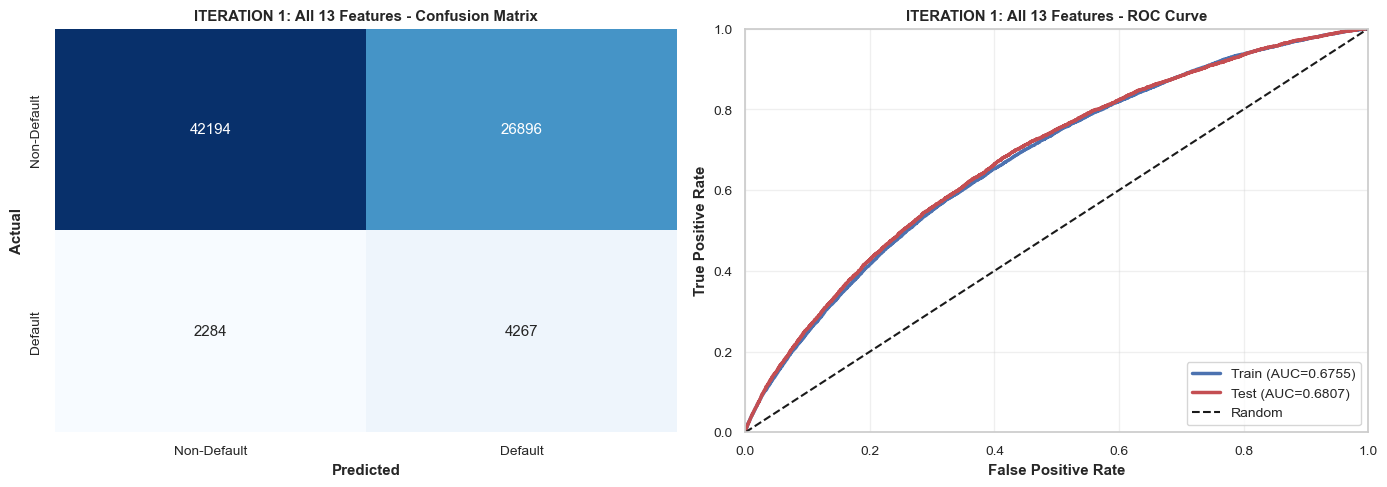

In [162]:
iter1_features = X.columns
iter1_results = train_and_evaluate_model(X_train, X_test, y_train, y_test, iter1_features, "ITERATION 1: All 13 Features")

### Model Iteration 2: Top-10 feature by coefficient

ITERATION 2: Top 10 Features
Number of features: 10
Train: AUC=0.6720 F1=0.2218 Acc=0.6098
Test:  AUC=0.6760 F1=0.2251 Acc=0.6106
Confusion Matrix - TN:41906 FP:27184 FN:2273 TP:4278
Classification Report (Test):
              precision    recall  f1-score   support

 Non-Default       0.95      0.61      0.74     69090
     Default       0.14      0.65      0.23      6551

    accuracy                           0.61     75641
   macro avg       0.54      0.63      0.48     75641
weighted avg       0.88      0.61      0.70     75641



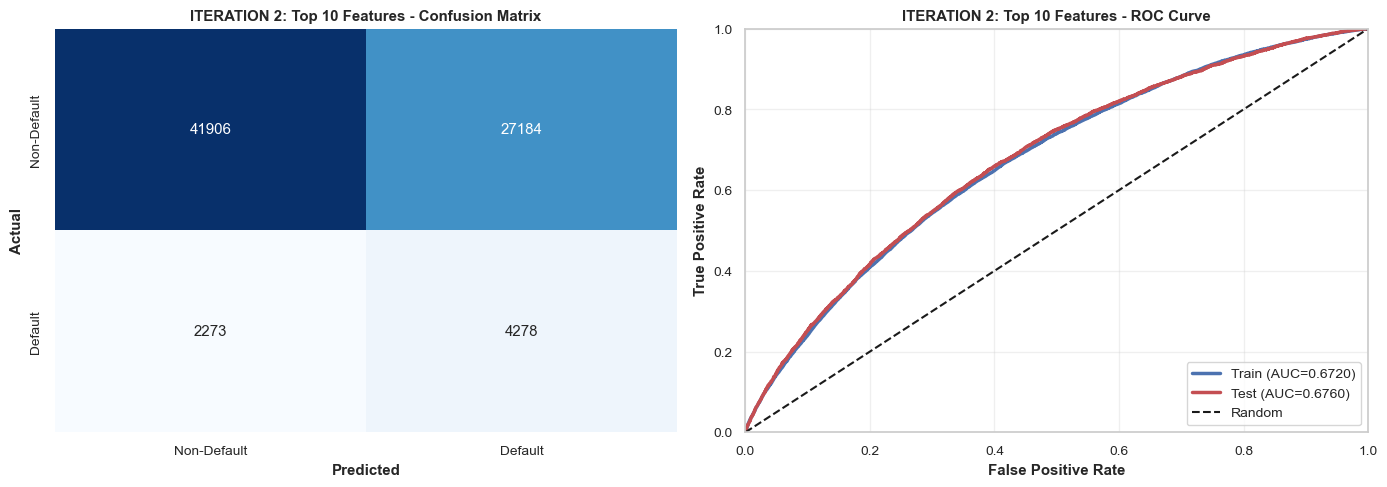

In [163]:
top_10_features = iter1_results['coefficients'].sort_values('Coefficient', key=abs, ascending=False).head(10)['Feature'].tolist()
X_train_iter2 = X_train[top_10_features]
X_test_iter2 = X_test[top_10_features]
iter2_results = train_and_evaluate_model(X_train_iter2, X_test_iter2, y_train, y_test, top_10_features, "ITERATION 2: Top 10 Features")

### Iteration 3: By Domain knowledge

ITERATION 3: Domain Knowledge (9 Features)
Number of features: 9
Train: AUC=0.6664 F1=0.2202 Acc=0.6114
Test:  AUC=0.6712 F1=0.2223 Acc=0.6127
Confusion Matrix - TN:42155 FP:26935 FN:2364 TP:4187
Classification Report (Test):
              precision    recall  f1-score   support

 Non-Default       0.95      0.61      0.74     69090
     Default       0.13      0.64      0.22      6551

    accuracy                           0.61     75641
   macro avg       0.54      0.62      0.48     75641
weighted avg       0.88      0.61      0.70     75641



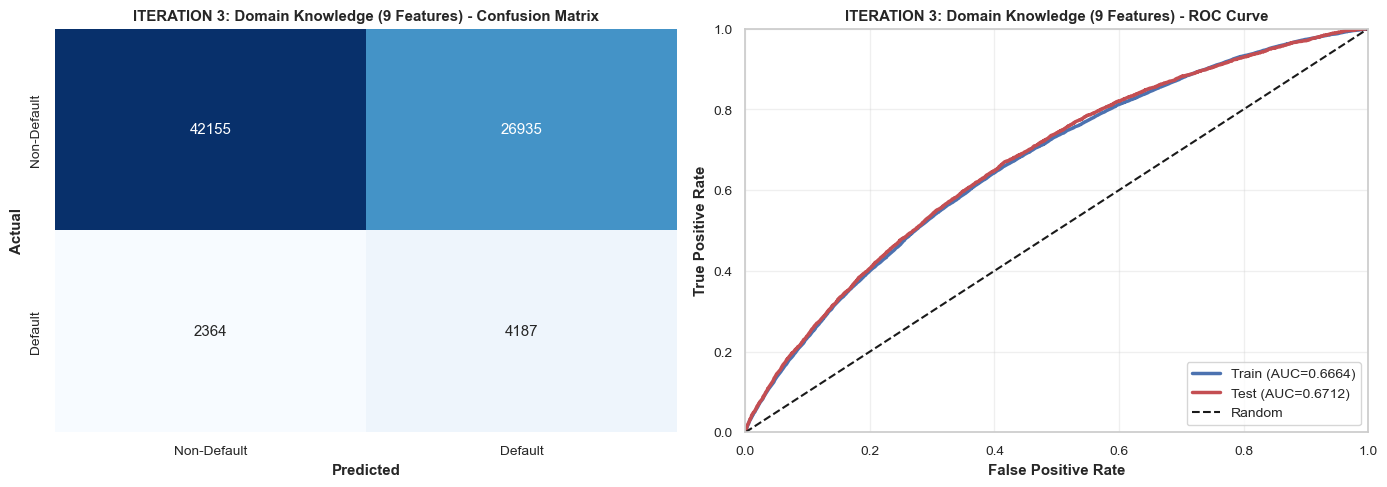

In [164]:
domain_features = ['debt_to_credit_woe', 'avg_days_credit_woe', 'DAYS_EMPLOYED_woe', 'num_active_woe', 'DAYS_LAST_PHONE_CHANGE_woe', 'NAME_INCOME_TYPE_woe', 'NAME_EDUCATION_TYPE_woe', 'ORGANIZATION_TYPE_woe', 'REGION_RATING_CLIENT_W_CITY_woe']
X_train_iter3 = X_train[domain_features]
X_test_iter3 = X_test[domain_features]
iter3_results = train_and_evaluate_model(X_train_iter3, X_test_iter3, y_train, y_test, domain_features, "ITERATION 3: Domain Knowledge (9 Features)")

### Overall comparison

In [165]:
comp_data = {
    'Iteration': ['Iter 1 (13)', 'Iter 2 (10)', 'Iter 3 (9)'],
    'Test_AUC': [iter1_results['test_metrics']['auc'], iter2_results['test_metrics']['auc'], iter3_results['test_metrics']['auc']],
    'Test_F1': [iter1_results['test_metrics']['f1'], iter2_results['test_metrics']['f1'], iter3_results['test_metrics']['f1']]
}
comp_df = pd.DataFrame(comp_data)
print("ITERATION COMPARISON")
print(comp_df.to_string(index=False))

ITERATION COMPARISON
  Iteration  Test_AUC  Test_F1
Iter 1 (13)  0.680697 0.226282
Iter 2 (10)  0.676001 0.225081
 Iter 3 (9)  0.671154 0.222281


In [258]:
best_idx = comp_df["Test_AUC"].idxmax()
models = [iter1_results, iter2_results, iter3_results]
best_model_results = models[best_idx]

print(f"\nBest Model: Iteration {best_idx + 1}")
print(f"Test AUC: {best_model_results['test_metrics']['auc']:.4f}")
print(f"Test F1: {best_model_results['test_metrics']['f1']:.4f}")

# Store best model variables for Section 3
selected_model = best_model_results['model']
fresh_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', class_weight='balanced')
fresh_model.fit(X_train, y_train)

selected_features = best_model_results['features']

print(f"\nBest model stored with {len(selected_features)} features")
print(f"Variables ready for Section 3:")
print(f"  - selected_model")
print(f"  - selected_features")
print(f"  - best_model_results")



Best Model: Iteration 1
Test AUC: 0.6807
Test F1: 0.2263

Best model stored with 13 features
Variables ready for Section 3:
  - selected_model
  - selected_features
  - best_model_results


## 3. Scorecard Generation and Tuning

In [195]:
# Load Best Model from Section 2
print("\n" + "="*70)
print("SECTION 3: SCORECARD GENERATION AND TUNING")
print("="*70)
print("\nLoading best model from iterative selection...")

try:
    print(f"Best Model Loaded")
    print(f"  Features: {len(selected_features)}")
    print(f"  Test AUC: {best_model_results['test_metrics']['auc']:.4f}")
    print(f"\nGenerating predictions for scorecard...")
    
    y_train_pred_best = selected_model.predict(X_train[selected_features])
    y_test_pred_best = selected_model.predict(X_test[selected_features])
    y_train_pred_proba_best = selected_model.predict_proba(X_train[selected_features])[:, 1]
    y_test_pred_proba_best = selected_model.predict_proba(X_test[selected_features])[:, 1]
    
    print(f"Predictions generated successfully")
    print(f"  Train predictions: {len(y_train_pred_proba_best):,} samples")
    print(f"  Test predictions: {len(y_test_pred_proba_best):,} samples")
    
except NameError as e:
    print(f"ERROR: {str(e)}")
    print("Variables not found from Section 2. Make sure to:")
    print("  1. Run all cells in Section 2 completely")
    print("  2. Especially the 'Iteration Comparison' and 'Best Model Selection' cells")
    print("  3. Then come back and run Section 3")



SECTION 3: SCORECARD GENERATION AND TUNING

Loading best model from iterative selection...
Best Model Loaded
  Features: 13
  Test AUC: 0.6807

Generating predictions for scorecard...
Predictions generated successfully
  Train predictions: 176,495 samples
  Test predictions: 75,641 samples


In [ ]:
# Calculate Risk Scores using Best Model Predictions
print("\n" + "="*70)
print("CREDIT RISK SCORE CALCULATION")
print("="*70)

points0 = 600
odds0 = 1/20
pdo = 20

def calculate_score(probability, points0, odds0, pdo):
    odds = probability / (1 - probability)
    score = points0 + (pdo / np.log(2)) * np.log(odds / odds0)
    return score

# score_from_model = points0 + (pdo / np.log(2)) * (log_odds - np.log(odds0))


train_score_best = calculate_score(y_train_pred_proba_best, points0, odds0, pdo)
test_score_best = calculate_score(y_test_pred_proba_best, points0, odds0, pdo)

print(f"Scorecard Parameters:")
print(f"  Base Points: {points0}")
print(f"  Base Odds: {odds0:.6f}")
print(f"  PDO: {pdo}")
print(f"\nCredit Score Statistics (Best Model):")
print(f"  Train - Mean: {train_score_best.mean():.2f}, Std: {train_score_best.std():.2f}, Min: {train_score_best.min():.2f}, Max: {train_score_best.max():.2f}")
print(f"  Test  - Mean: {test_score_best.mean():.2f}, Std: {test_score_best.std():.2f}, Min: {test_score_best.min():.2f}, Max: {test_score_best.max():.2f}")





CREDIT RISK SCORE CALCULATION
Scorecard Parameters:
  Base Points: 600
  Base Odds: 0.050000
  PDO: 20

Credit Score Statistics (Best Model):
  Train - Mean: 681.36, Std: 19.39, Min: 596.67, Max: 740.52
  Test  - Mean: 681.32, Std: 19.36, Min: 604.71, Max: 738.60



SCORE DISTRIBUTION - ENTIRE POPULATION

Combined Score Statistics:
  Total observations: 252,136
  Mean: 681.34
  Std Dev: 19.38
  Min: 596.67
  Max: 740.52
  Median: 681.94
  25th percentile: 668.32
  75th percentile: 695.17


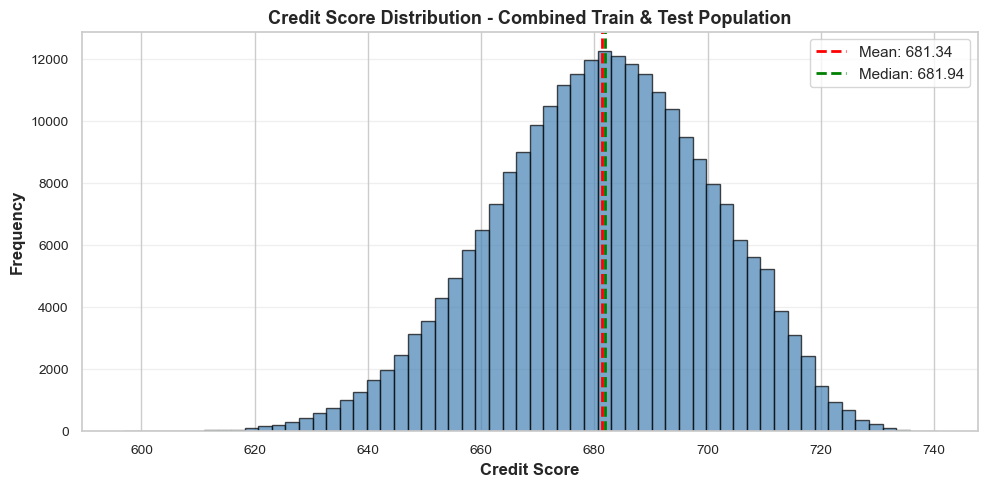

In [243]:
# Combined Score Distribution - Entire Population
combined_score = pd.concat([pd.Series(train_score_best), pd.Series(test_score_best)], ignore_index=True)

print("\n" + "="*70)
print("SCORE DISTRIBUTION - ENTIRE POPULATION")
print("="*70)
print(f"\nCombined Score Statistics:")
print(f"  Total observations: {len(combined_score):,}")
print(f"  Mean: {combined_score.mean():.2f}")
print(f"  Std Dev: {combined_score.std():.2f}")
print(f"  Min: {combined_score.min():.2f}")
print(f"  Max: {combined_score.max():.2f}")
print(f"  Median: {combined_score.median():.2f}")
print(f"  25th percentile: {combined_score.quantile(0.25):.2f}")
print(f"  75th percentile: {combined_score.quantile(0.75):.2f}")

plt.figure(figsize=(10, 5))
combined_score.hist(bins=60, edgecolor="black", alpha=0.7, color="steelblue")
plt.xlabel("Credit Score", fontsize=12, fontweight="bold")
plt.ylabel("Frequency", fontsize=12, fontweight="bold")
plt.title("Credit Score Distribution - Combined Train & Test Population", fontsize=13, fontweight="bold")
plt.axvline(combined_score.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {combined_score.mean():.2f}")
plt.axvline(combined_score.median(), color="green", linestyle="--", linewidth=2, label=f"Median: {combined_score.median():.2f}")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [244]:
# CUTOFF OPTIMIZATION - Recommended Cutoff with Statistical Metrics
print("\n" + "="*70)
print("SCORECARD TUNING: CUTOFF OPTIMIZATION")
print("="*70)

# Score distribution statistics
print("\nScore Statistics (Test Set):")
print(f"  Score Range: {test_score_best.min():.2f} to {test_score_best.max():.2f}")
print(f"  Mean: {test_score_best.mean():.2f}")
print(f"  Std Dev: {test_score_best.std():.2f}")

cutoffs = list(range(500,800,10))


SCORECARD TUNING: CUTOFF OPTIMIZATION

Score Statistics (Test Set):
  Score Range: 604.71 to 738.60
  Mean: 681.32
  Std Dev: 19.36


In [245]:
# BUSINESS IMPACT ANALYSIS - Using Formula-Based Default Rate at Each Cutoff
print("\n" + "="*70)
print("BUSINESS IMPACT ANALYSIS: Cutoff Score Tuning")
print("="*70)

def score_to_default_probability(score, points0, odds0, pdo):
    odds = odds0 * np.exp((np.log(2) / pdo) * (points0 - score))
    return odds / (1 + odds)

avg_revenue_per_loan = 1500
avg_loss_per_default = 10000
total_loans_applied = 10000

print(f"\nBusiness Parameters:")
print(f"  Total loans applied: {total_loans_applied:,}")
print(f"  Average revenue per loan: ${avg_revenue_per_loan:,}")
print(f"  Average loss per default: ${avg_loss_per_default:,}")

print(f"\nScorecard Parameters:")
print(f"  PDO: {pdo}")
print(f"  Odds0: {odds0:.6f}")
print(f"  Points0: {points0}")

results = []
for cutoff in cutoffs:
    approval_rate = (test_score_best >= cutoff).sum() / len(test_score_best)
    default_rate_at_cutoff = score_to_default_probability(cutoff, points0, odds0, pdo)
    approved_loans = int(total_loans_applied * approval_rate)
    expected_defaults = int(approved_loans * default_rate_at_cutoff)
    total_revenue = approved_loans * avg_revenue_per_loan
    total_loss = expected_defaults * avg_loss_per_default
    net_profit = total_revenue - total_loss
    profit_per_loan = net_profit / total_loans_applied
    results.append({"Cutoff": cutoff, "Approval_Rate": approval_rate, "Default_Rate": default_rate_at_cutoff, "Approved_Loans": approved_loans, "Expected_Defaults": expected_defaults, "Revenue": total_revenue, "Loss": total_loss, "Net_Profit": net_profit, "Profit_Per_Loan": profit_per_loan})

business_df = pd.DataFrame(results)
print("\nBusiness Impact (Default Rate by Formula at Each Cutoff):")
for _, row in business_df.iterrows():
    cutoff = row["Cutoff"]
    appr = row["Approval_Rate"]*100
    default = row["Default_Rate"]*100
    approved = row["Approved_Loans"]
    defs = row["Expected_Defaults"]
    revenue = row["Revenue"]
    loss = row["Loss"]
    profit = row["Net_Profit"]
    print(f"Cutoff {cutoff:.0f}: Appr {appr:.1f}% | Def {default:.2f}% | Approved {approved:,.0f} | Defaults {defs:,.0f} | Revenue ${revenue:,.0f} | Loss ${loss:,.0f} | Profit ${profit:,.0f}")

optimal_idx = business_df["Net_Profit"].idxmax()
opt_cutoff = business_df.loc[optimal_idx, "Cutoff"]
opt_profit = business_df.loc[optimal_idx, "Net_Profit"]
opt_default = business_df.loc[optimal_idx, "Default_Rate"]
print("\n" + "="*70)
print(f"OPTIMAL CUTOFF (Maximum Profit): {opt_cutoff:.0f}")
print(f"  Default Rate (by formula): {opt_default*100:.2f}%")
print(f"  Net Profit: ${opt_profit:,.0f}")


BUSINESS IMPACT ANALYSIS: Cutoff Score Tuning

Business Parameters:
  Total loans applied: 10,000
  Average revenue per loan: $1,500
  Average loss per default: $10,000

Scorecard Parameters:
  PDO: 20
  Odds0: 0.050000
  Points0: 600

Business Impact (Default Rate by Formula at Each Cutoff):
Cutoff 500: Appr 100.0% | Def 61.54% | Approved 10,000 | Defaults 6,153 | Revenue $15,000,000 | Loss $61,530,000 | Profit $-46,530,000
Cutoff 510: Appr 100.0% | Def 53.08% | Approved 10,000 | Defaults 5,308 | Revenue $15,000,000 | Loss $53,080,000 | Profit $-38,080,000
Cutoff 520: Appr 100.0% | Def 44.44% | Approved 10,000 | Defaults 4,444 | Revenue $15,000,000 | Loss $44,440,000 | Profit $-29,440,000
Cutoff 530: Appr 100.0% | Def 36.13% | Approved 10,000 | Defaults 3,613 | Revenue $15,000,000 | Loss $36,130,000 | Profit $-21,130,000
Cutoff 540: Appr 100.0% | Def 28.57% | Approved 10,000 | Defaults 2,857 | Revenue $15,000,000 | Loss $28,570,000 | Profit $-13,570,000
Cutoff 550: Appr 100.0% | Def 

In [246]:
# Create a copy for display to avoid modifying the original data
display_df = business_df.copy()

# 1. Apply formatting for better readability
format_mapping = {
    "Cutoff": "{:.0f}",
    "Approval_Rate": "{:.2%}",
    "Default_Rate": "{:.2%}",
    "Approved_Loans": "{:,.0f}",
    "Expected_Defaults": "{:,.0f}",
    "Revenue": "${:,.0f}",
    "Loss": "${:,.0f}",
    "Net_Profit": "${:,.0f}",
    "Profit_Per_Loan": "${:,.2f}"
}

# 2. Display the DataFrame
# If using Jupyter/Colab, this will show a nice HTML table
print("BUSINESS IMPACT ANALYSIS TABLE")
display(display_df.style.format(format_mapping).highlight_max(subset=['Net_Profit'], color='lightgreen'))

BUSINESS IMPACT ANALYSIS TABLE


,Cutoff,Approval_Rate,Default_Rate,Approved_Loans,Expected_Defaults,Revenue,Loss,Net_Profit,Profit_Per_Loan
0,500,100.00%,61.54%,"10,000","6,153","$15,000,000","$61,530,000","$-46,530,000","$-4,653.00"
1,510,100.00%,53.08%,"10,000","5,308","$15,000,000","$53,080,000","$-38,080,000","$-3,808.00"
2,520,100.00%,44.44%,"10,000","4,444","$15,000,000","$44,440,000","$-29,440,000","$-2,944.00"
3,530,100.00%,36.13%,"10,000","3,613","$15,000,000","$36,130,000","$-21,130,000","$-2,113.00"
4,540,100.00%,28.57%,"10,000","2,857","$15,000,000","$28,570,000","$-13,570,000","$-1,357.00"
5,550,100.00%,22.05%,"10,000","2,204","$15,000,000","$22,040,000","$-7,040,000",$-704.00
6,560,100.00%,16.67%,"10,000","1,666","$15,000,000","$16,660,000","$-1,660,000",$-166.00
7,570,100.00%,12.39%,"10,000","1,238","$15,000,000","$12,380,000","$2,620,000",$262.00
8,580,100.00%,9.09%,"10,000",909,"$15,000,000","$9,090,000","$5,910,000",$591.00
9,590,100.00%,6.60%,"10,000",660,"$15,000,000","$6,600,000","$8,400,000",$840.00


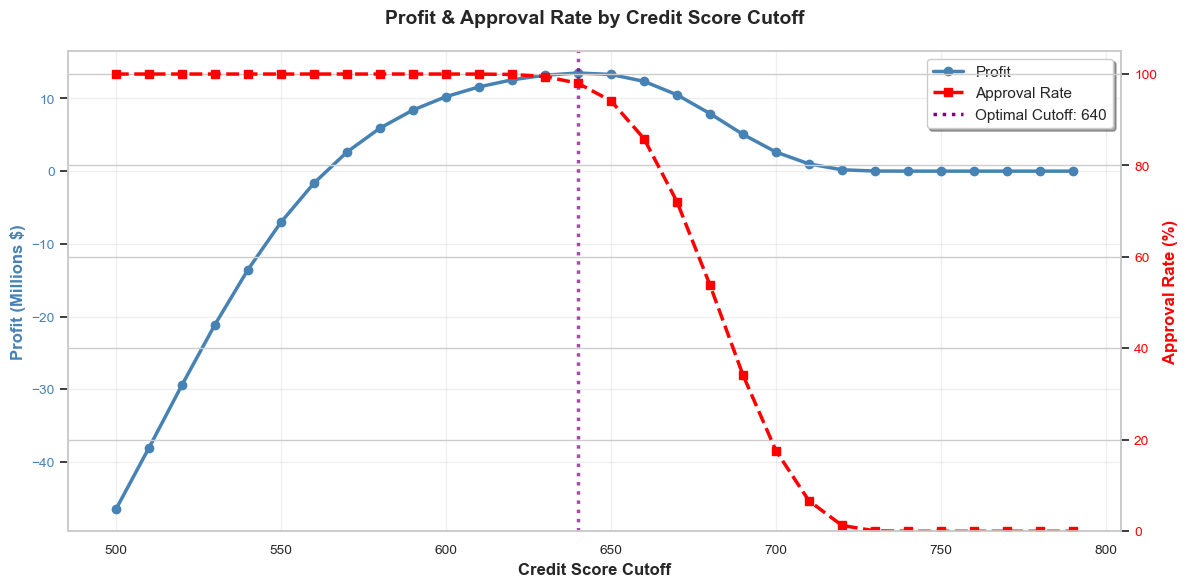


OPTIMAL CUTOFF ANALYSIS

Optimal Cutoff: 640
  Approval Rate: 98.0%
  Default Rate (formula): 1.23%
  Approved Loans: 9799
  Expected Defaults: 120
  Net Profit: $13,498,500

Profit at Cutoff 640: $13.50M


In [247]:
# Visualization: Dual-Axis Plot - Profit & Approval Rate by Cutoff
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1 (Left): Profit in millions
color1 = "steelblue"
ax1.set_xlabel("Credit Score Cutoff", fontsize=12, fontweight="bold")
ax1.set_ylabel("Profit (Millions $)", fontsize=12, fontweight="bold", color=color1)
line1 = ax1.plot(business_df["Cutoff"], business_df["Net_Profit"]/1e6, color=color1, marker="o", linewidth=2.5, markersize=6, label="Profit")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Axis 2 (Right): Approval Rate
ax2 = ax1.twinx()
color2 = "red"
ax2.set_ylabel("Approval Rate (%)", fontsize=12, fontweight="bold", color=color2)
line2 = ax2.plot(business_df["Cutoff"], business_df["Approval_Rate"]*100, color=color2, marker="s", linewidth=2.5, markersize=6, label="Approval Rate", linestyle="--")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim([0, 105])

# Mark optimal cutoff
best_profit_idx = business_df["Net_Profit"].idxmax()
optimal_cutoff = business_df.loc[best_profit_idx, "Cutoff"]
ax1.axvline(x=optimal_cutoff, color="purple", linestyle=":", linewidth=2.5, alpha=0.7, label=f"Optimal Cutoff: {optimal_cutoff:.0f}")

# Title and legend - UPDATED
plt.title("Profit & Approval Rate by Credit Score Cutoff", fontsize=14, fontweight="bold", pad=20)
lines = line1 + line2 + [plt.Line2D([0], [0], color="purple", linestyle=":", linewidth=2.5)]
labels = ["Profit", "Approval Rate", f"Optimal Cutoff: {optimal_cutoff:.0f}"]

# Changed loc to 'upper right' and removed bbox_to_anchor
ax1.legend(lines, labels, loc="upper right", fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Summary
best_profit = business_df.loc[best_profit_idx]
print("\n" + "="*70)
print("OPTIMAL CUTOFF ANALYSIS")
print("="*70)
opt_cutoff_val = best_profit["Cutoff"]
opt_appr = best_profit["Approval_Rate"]*100
opt_default = best_profit["Default_Rate"]*100
opt_approved = best_profit["Approved_Loans"]
opt_defaults = best_profit["Expected_Defaults"]
opt_profit = best_profit["Net_Profit"]
opt_profit_m = opt_profit / 1e6
print(f"\nOptimal Cutoff: {opt_cutoff_val:.0f}")
print(f"  Approval Rate: {opt_appr:.1f}%")
print(f"  Default Rate (formula): {opt_default:.2f}%")
print(f"  Approved Loans: {opt_approved:.0f}")
print(f"  Expected Defaults: {opt_defaults:.0f}")
print(f"  Net Profit: ${opt_profit:,.0f}")
print(f"\nProfit at Cutoff {opt_cutoff_val:.0f}: ${opt_profit_m:.2f}M")


## Scorecard

In [248]:
import pickle
import pandas as pd
from pathlib import Path

# Use pathlib for a robust relative path
pkl_path = Path("../outputs/bins_dict.pkl")

if pkl_path.exists():
    with open(pkl_path, 'rb') as f:
        bins_dict_lists = pickle.load(f)
    
    # Convert lists to DataFrames
    bins = {variable: pd.DataFrame(bl) for variable, bl in bins_dict_lists.items()}
    print("Successfully loaded bins_dict.")
else:
    print(f"Error: The file was not found at {pkl_path.absolute()}")
    print("Hint: You likely need to run the Step 3 grouping script first.")

Successfully loaded bins_dict.


In [270]:
# FULL CREDIT SCORECARD GENERATION (Using scorecardpy)
import scorecardpy as sc
import pprint

print("FULL CREDIT SCORECARD")
print("="*150)

# User's exact parameters
target_score = 640
target_odds = 20  
pdo = 20
odds0 = 1/target_odds  

print(f"Parameters:")
print(f"  Target Score: {target_score}")
print(f"  Target Odds: 1:{target_odds}")
print(f"  PDO: {pdo}")
print()
# Generate scorecard using scorecardpy
# This automatically handles the mathematical transformations correctly
card = sc.scorecard(bins, selected_model, selected_features, 
                    points0=target_score, odds0=odds0, pdo=pdo, basepoints_eq0=False)

print("[SUCCESS] Scorecard generated using scorecardpy")
print()

# Convert card to DataFrame for display
scorecard_data = []
for variable, card_df in card.items():
    if variable != 'basepoints':
        for _, row in card_df.iterrows():
            scorecard_data.append({
                "Variable": row['variable'],
                "Bin": row['bin'],
                "Points": f"{row['points']}"
            })

scorecard_df = pd.DataFrame(scorecard_data)
print(f"Scorecard complete: {len(scorecard_df)} total rows")
print()

# Display card structure

print("Scorecard Details:")
scorecard_df

FULL CREDIT SCORECARD
Parameters:
  Target Score: 640
  Target Odds: 1:20
  PDO: 20

[SUCCESS] Scorecard generated using scorecardpy

Scorecard complete: 51 total rows

Scorecard Details:


,Variable,Bin,Points
0,avg_days_credit,missing,-3.0
1,avg_days_credit,"[-inf,-1300.0)",6.0
2,avg_days_credit,"[-1300.0,-850.0)",2.0
3,avg_days_credit,"[-850.0,-350.0)",-2.0
4,avg_days_credit,"[-350.0,inf)",-7.0
5,debt_to_credit,missing,-4.0
6,debt_to_credit,"[-inf,0.2000000000000015)",5.0
7,debt_to_credit,"[0.2000000000000015,0.4000000000000017)",2.0
8,debt_to_credit,"[0.4000000000000017,0.6000000000000019)",-2.0
9,debt_to_credit,"[0.6000000000000019,inf)",-6.0


In [264]:
# 1. Define a Sample Applicant
# We use values that fall into the high-point bins based on your scorecard
sample_data = {
    'avg_days_credit': [-1500],           # Bin: [-inf, -1300.0) -> 43 pts
    'debt_to_credit': [0.1],              # Bin: [-inf, 0.20) -> 42 pts
    'DAYS_EMPLOYED': [5000],              # Bin: [4000.0, inf) -> 49 pts
    'OCCUPATION_TYPE': ['Accountants'],    # Bin: High Skill -> 42 pts
    'AMT_GOODS_PRICE': [1500000],         # Bin: [1,300,000, inf) -> 52 pts
    'NAME_EDUCATION_TYPE': ['Higher education'], # Bin: Academic degree... -> 46 pts
    'REGION_RATING_CLIENT_W_CITY': [1],   # Bin: [-inf, 2.0) -> 52 pts
    'DAYS_LAST_PHONE_CHANGE': [2500],     # Bin: [2100.0, inf) -> 44 pts
    'num_active': [0],                    # Bin: [-inf, 1.0) -> 44 pts
    'ORGANIZATION_TYPE': ['Trade: type 4'], # Bin: Type Group A -> 45 pts
    'NAME_INCOME_TYPE': ['State servant'], # Bin: State servant... -> 41 pts
    'EMERGENCYSTATE_MODE': ['No'],        # Bin: No/Yes -> 39 pts
    'HOUSETYPE_MODE': ['block of flats']  # Bin: block of flats... -> 38 pts
}

sample_df = pd.DataFrame(sample_data)

# 2. Calculate the Total Score
# sc.scorecard_ply maps the raw data to the scorecard points automatically
sample_score = sc.scorecard_ply(sample_df, card, print_step=0)

print("="*30)
print(f"SAMPLE APPLICANT SCORE: {sample_score.iloc[0,0]:.2f}")
print("="*30)

# 3. Optional: See the breakdown of points per variable
# Setting only_total_score=False returns the points assigned for each feature
score_breakdown = sc.scorecard_ply(sample_df, card, only_total_score=False, print_step=0)

print("\nPoint Breakdown per Variable:")
print(score_breakdown.T) # Transposed for easier reading

SAMPLE APPLICANT SCORE: 644.00

Point Breakdown per Variable:
                                        0
avg_days_credit_points               48.0
debt_to_credit_points                48.0
DAYS_EMPLOYED_points                 54.0
OCCUPATION_TYPE_points               47.0
AMT_GOODS_PRICE_points               57.0
NAME_EDUCATION_TYPE_points           51.0
REGION_RATING_CLIENT_W_CITY_points   57.0
DAYS_LAST_PHONE_CHANGE_points        49.0
num_active_points                    49.0
ORGANIZATION_TYPE_points             50.0
NAME_INCOME_TYPE_points              46.0
EMERGENCYSTATE_MODE_points           45.0
HOUSETYPE_MODE_points                43.0
score                               644.0


In [251]:
# 1. Define a Sample Applicant
# We use values that fall into the high-point bins based on your scorecard
negative_sample_data = {
    'avg_days_credit': [-100],              # Bin: [-350.0, inf) -> 35 pts
    'debt_to_credit': [0.95],               # Bin: [0.60, inf) -> 36 pts
    'DAYS_EMPLOYED': [500],                 # Bin: [-inf, 1000.0) -> 37 pts
    'OCCUPATION_TYPE': ['Drivers'],         # Bin: Waiters/Drivers/Laborers -> 37 pts
    'AMT_GOODS_PRICE': [400000],            # Bin: [300000.0, 500000.0) -> 37 pts
    'NAME_EDUCATION_TYPE': ['Incomplete higher'],   # Bin: Secondary / secondary spec -> 40 pts
    'REGION_RATING_CLIENT_W_CITY': [3],     # Bin: [3.0, inf) -> 32 pts
    'DAYS_LAST_PHONE_CHANGE': [100],        # Bin: [-inf, 1100.0) -> 40 pts
    'num_active': [6],                      # Bin: [5.0, inf) -> 35 pts
    'ORGANIZATION_TYPE': ['Cleaning'],      # Bin: Industry type 3/Cleaning -> 37 pts
    'NAME_INCOME_TYPE': ['Working'],        # Bin: Working / Maternity leave -> 41 pts
    'EMERGENCYSTATE_MODE': ['Yes'],         # Bin: No/Yes -> 44 pts (High relative to missing)
    'HOUSETYPE_MODE': ['terraced house']    # Bin: block of flats/terraced -> 42 pts
}

sample_df = pd.DataFrame(negative_sample_data)

# 2. Calculate the Total Score
# sc.scorecard_ply maps the raw data to the scorecard points automatically
sample_score = sc.scorecard_ply(sample_df, card, print_step=0)

print("="*30)
print(f"SAMPLE APPLICANT SCORE: {sample_score.iloc[0,0]:.2f}")
print("="*30)

# 3. Optional: See the breakdown of points per variable
# Setting only_total_score=False returns the points assigned for each feature
score_breakdown = sc.scorecard_ply(sample_df, card, only_total_score=False, print_step=0)

print("\nPoint Breakdown per Variable:")
print(score_breakdown.T) # Transposed for easier reading

SAMPLE APPLICANT SCORE: 498.00

Point Breakdown per Variable:
                                        0
avg_days_credit_points               35.0
debt_to_credit_points                36.0
DAYS_EMPLOYED_points                 37.0
OCCUPATION_TYPE_points               38.0
AMT_GOODS_PRICE_points               37.0
NAME_EDUCATION_TYPE_points           40.0
REGION_RATING_CLIENT_W_CITY_points   33.0
DAYS_LAST_PHONE_CHANGE_points        40.0
num_active_points                    35.0
ORGANIZATION_TYPE_points             37.0
NAME_INCOME_TYPE_points              42.0
EMERGENCYSTATE_MODE_points           45.0
HOUSETYPE_MODE_points                43.0
score                               498.0


In [252]:
# VALIDATE: Scorecard vs Model Prediction (Using WOE-encoded data)                                                                                                                                                                                                                                                                                    
print("VALIDATION: Scorecard vs Model Prediction")
print("="*100)                                                                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                                                                                    
# Test on a few samples from test set
test_indices = [0, 100, 500]

for idx in test_indices:
    if idx < len(X_test):
        # Method 1: Using calculate_score (from predicted probability)
        pred_prob = y_test_pred_proba_best[idx]
        score_from_prob = calculate_score(pred_prob, points0, odds0, pdo)

        # Method 2: Direct from logistic regression coefficients
        log_odds = selected_model.intercept_[0] + sum(
            selected_model.coef_[0][i] * X_test.iloc[idx, i]
            for i in range(len(selected_features))
        )
        score_from_model = points0 + (pdo / np.log(2)) * (log_odds - np.log(odds0))

        diff = abs(score_from_prob - score_from_model)
        print(f"Sample {idx}:")
        print(f"  Pred Probability: {pred_prob:.4f}")
        print(f"  Score (from prob): {score_from_prob:.2f}")
        print(f"  Score (from model): {score_from_model:.2f}")
        print(f"  Difference: {diff:.4f}")

print("=" + "="*99)
print("Note: Differences should be < 0.01 (machine precision).")

VALIDATION: Scorecard vs Model Prediction
Sample 0:
  Pred Probability: 0.7915
  Score (from prob): 724.94
  Score (from model): 724.94
  Difference: 0.0000
Sample 100:
  Pred Probability: 0.3460
  Score (from prob): 668.07
  Score (from model): 668.07
  Difference: 0.0000
Sample 500:
  Pred Probability: 0.5496
  Score (from prob): 692.18
  Score (from model): 692.18
  Difference: 0.0000
Note: Differences should be < 0.01 (machine precision).
